In [4]:
# ============================================================
# Proyecto M3 - Opción B: Reclamo de Seguro
# LangGraph con CSV externo, Checkpoint, Replay, Fork y Loop controlado
# ============================================================

!pip install -q langgraph langchain langchain-openai typing_extensions pandas

import pandas as pd
from typing_extensions import TypedDict, NotRequired, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from pprint import pprint
from datetime import datetime

# ------------------------------------------------------------
# 1. Cargar archivo externo de pólizas
# ------------------------------------------------------------
polizas_df = pd.read_csv("polizas.csv")

# ------------------------------------------------------------
# 2. Definición del estado
# ------------------------------------------------------------
class ReclamoState(TypedDict):
    reclamo_id: str
    cliente: str
    poliza: str
    descripcion: str
    tipo_reclamo: NotRequired[str]
    tipo_poliza: NotRequired[str]
    cobertura: NotRequired[str]
    vencimiento: NotRequired[str]
    monto_estimado: NotRequired[float]
    decision: NotRequired[str]
    requiere_aprobacion: NotRequired[bool]
    decision_humana: NotRequired[str]
    errores: NotRequired[list[str]]
    eventos: Annotated[list[str], add]
    intentos: NotRequired[int]

# ------------------------------------------------------------
# 3. Nodos principales
# ------------------------------------------------------------
def recibir_reclamo(state: ReclamoState):
    return {"eventos": [f"Reclamo {state['reclamo_id']} recibido de cliente {state['cliente']} "]}

def validar_poliza(state: ReclamoState):
    registro = polizas_df[
        (polizas_df["cliente"] == state["cliente"]) &
        (polizas_df["poliza"] == state["poliza"])
    ]
    if registro.empty or pd.isna(registro.iloc[0]["poliza"]):
        return {
            "errores": ["El cliente no tiene póliza registrada."],
            "eventos": ["Error: cliente sin póliza en archivo externo."],
            "decision": "Sin póliza"
        }
    return {
        "tipo_poliza": registro.iloc[0]["tipo_poliza"],
        "eventos": [f"Póliza válida: {registro.iloc[0]['tipo_poliza']}"]
    }

def validar_cobertura(state: ReclamoState):
    if "errores" in state:
        return {}
    registro = polizas_df[
        (polizas_df["cliente"] == state["cliente"]) &
        (polizas_df["poliza"] == state["poliza"])
    ]
    if registro.empty or pd.isna(registro.iloc[0]["cobertura"]):
        return {
            "errores": ["El cliente no tiene cobertura registrada."],
            "eventos": ["Error: cliente sin cobertura en archivo externo."],
            "decision": "Sin cobertura"
        }

    cobertura = registro.iloc[0]["cobertura"]
    vencimiento = registro.iloc[0]["vencimiento"]
    monto = float(registro.iloc[0]["monto_cobertura"])

    hoy = datetime.today().date()
    fecha_venc = datetime.strptime(vencimiento, "%Y-%m-%d").date()
    if fecha_venc < hoy:
        return {
            "errores": ["La póliza está vencida."],
            "eventos": [f"Error: póliza vencida (venció el {vencimiento})."],
            "decision": "Sin cobertura"
        }

    return {
        "cobertura": cobertura,
        "vencimiento": vencimiento,
        "monto_estimado": monto,
        "eventos": [
            f"Cobertura validada: {cobertura}.",
            f"Vencimiento: {vencimiento}, monto máximo: {monto}"
        ]
    }

def estimar_monto(state: ReclamoState):
    if "errores" in state:
        return {}

    cobertura = state.get("cobertura", "").lower()
    monto_base = state.get("monto_estimado", 0)

    if cobertura == "total":
        monto_estimado = monto_base * 0.9
        evento = f"Monto estimado calculado: 90% de {monto_base} = {monto_estimado}."
    elif cobertura == "parcial":
        monto_estimado = monto_base * 0.4
        evento = f"Monto estimado calculado: 40% de {monto_base} = {monto_estimado}."
    else:
        monto_estimado = monto_base
        evento = f"Monto estimado sin ajuste: {monto_estimado}."

    return {
        "monto_estimado": monto_estimado,
        "eventos": [evento]
    }

def tomar_decision(state: ReclamoState):
    intentos = state.get("intentos", 0) + 1
    updates = {"intentos": intentos, "eventos": []}

    decision = state.get("decision", "Revisión")

    if "errores" in state:
        decision = state.get("decision")
        updates["eventos"].append(f"Decisión final (error): {decision}.")
    elif state.get("decision_humana") == "Aprobado":
        decision = "Aprobado"
        updates["requiere_aprobacion"] = False # No más requirimiento si el humnao decidió
        updates["eventos"].append(f"Decisión final (humana): {decision}.")
    elif state.get("decision_humana") == "Rechazado":
        decision = "Rechazado"
        updates["requiere_aprobacion"] = False # No más requirimiento si el humnao decidió
        updates["eventos"].append(f"Decisión final (humana): {decision}.")
    else:
        monto = state.get("monto_estimado", 0)
        if monto <= 3000:
            decision = "Aprobado"
            updates["eventos"].append("Monto bajo: aprobado automáticamente.")
        elif monto > 3000:
            if intentos >= 2:   # 👈 límite de intentos
                decision = "Revisión"
                updates["requiere_aprobacion"] = False # Restablecer si se alcanza el número máximo de intentos.
                updates["eventos"].append("Se alcanzó el límite de intentos sin decisión humana.")
            else:
                decision = "Pendiente"
                updates["requiere_aprobacion"] = True # Requiere aprobación humana
                updates["eventos"].append("Monto alto: requiere aprobación humana.")
        else:
            decision = "Revisión"

    updates["decision"] = decision
    updates["eventos"].append(f"Decisión actual: {decision}.") # Add current decision to events
    return updates

def solicitar_aprobacion(state: ReclamoState):
    return {"eventos": ["Esperando decisión humana..."]}

def generar_respuesta(state: ReclamoState):
    return {
        "eventos": [f"Respuesta final para el cliente: {state.get('decision', 'Revisión')}!"]
    }

# ------------------------------------------------------------
# 4. Construcción del grafo con loop controlado
# ------------------------------------------------------------
builder = StateGraph(ReclamoState)
builder.add_node("recibir_reclamo", recibir_reclamo)
builder.add_node("validar_poliza", validar_poliza)
builder.add_node("validar_cobertura", validar_cobertura)
builder.add_node("estimar_monto", estimar_monto)
builder.add_node("tomar_decision", tomar_decision)
builder.add_node("solicitar_aprobacion", solicitar_aprobacion)
builder.add_node("generar_respuesta", generar_respuesta)

builder.add_edge(START, "recibir_reclamo")
builder.add_edge("recibir_reclamo", "validar_poliza")
builder.add_edge("validar_poliza", "validar_cobertura")
builder.add_edge("validar_cobertura", "estimar_monto")
builder.add_edge("estimar_monto", "tomar_decision")

# Condicional directo desde tomar_decision
builder.add_conditional_edges(
    "tomar_decision",
    lambda state: "solicitar" if state.get("decision") == "Pendiente" else "respuesta",
    {
        "solicitar": "solicitar_aprobacion",
        "respuesta": "generar_respuesta"
    }
)

# Loop: solicitar_aprobacion regresa a tomar_decision
builder.add_edge("solicitar_aprobacion", "tomar_decision")

# Generar respuesta finaliza
builder.add_edge("generar_respuesta", END)

checkpointer = InMemorySaver()
reclamo_graph = builder.compile(checkpointer=checkpointer)


# ------------------------------------------------------------
# 5. Ejemplos de pruebas
# ------------------------------------------------------------

# ------------------------------------------------------------
# 5. Ejemplos de pruebas
# ------------------------------------------------------------

# Caso 1: Normal sin validación humana (monto bajo → aprobado automático)
print("\n=== Caso 1: Normal sin validación humana (monto bajo) ===")
config1 = {"configurable": {"thread_id": "thread-caso1"}}
input1 = {"reclamo_id": "R-014A", "cliente": "Lucía Fernández", "poliza": "POL-55555",
          "descripcion": "Reclamo por daños menores", "tipo_reclamo": "Hogar",
          "eventos": [], "intentos": 0}
resultado1 = reclamo_graph.invoke(input1, config1)
pprint(resultado1)

# Caso 2: Normal con checkpoint antes de cobertura
print("\n=== Caso 2: Checkpoint antes de cobertura ===")
config2 = {"configurable": {"thread_id": "thread-caso2"}}
input2 = {"reclamo_id": "R-014B", "cliente": "Juan Pérez", "poliza": "POL-12345",
          "descripcion": "Accidente de tránsito leve", "tipo_reclamo": "Accidente",
          "eventos": [], "intentos": 0}
resultado2 = reclamo_graph.invoke(input2, config2)
historial2 = list(reclamo_graph.get_state_history(config2))
before_cobertura = next(snapshot for snapshot in historial2 if snapshot.next == ("validar_cobertura",))
print("Checkpoint antes de cobertura:")
pprint(before_cobertura.values)

print("\n Reprocesa desde cobertura")
resultado_replay = reclamo_graph.invoke(None, before_cobertura.config)
pprint(resultado_replay)

# Caso 3: Normal con validación humana (monto alto → requiere aprobación)
print("\n=== Caso 3A: Validación humana - APROBADO ===")
config3 = {"configurable": {"thread_id": "thread-caso3"}}
input3 = {"reclamo_id": "R-014C", "cliente": "Carlos Ramírez", "poliza": "POL-99999",
          "descripcion": "Accidente vehicular grave", "tipo_reclamo": "Accidente",
          "eventos": [], "intentos": 0}
resultado3 = reclamo_graph.invoke(input3, config3)
historial3 = list(reclamo_graph.get_state_history(config3))
before_decision = next(snapshot for snapshot in historial3 if snapshot.next == ("tomar_decision",))
fork_config_aprobado = reclamo_graph.update_state(before_decision.config, values={"decision_humana": "Aprobado"})
pprint(reclamo_graph.invoke(None, fork_config_aprobado))

print("\n=== Caso 3B: Validación humana - RECHAZADO ===")
fork_config_rechazado = reclamo_graph.update_state(before_decision.config, values={"decision_humana": "Rechazado"})
pprint(reclamo_graph.invoke(None, fork_config_rechazado))

# Caso 4: Cliente sin póliza
print("\n=== Caso 4: Cliente sin póliza ===")
config4 = {"configurable": {"thread_id": "thread-caso4"}}
input4 = {"reclamo_id": "R-014D", "cliente": "Pedro Gómez", "poliza": "",
          "descripcion": "Accidente de tránsito", "tipo_reclamo": "Accidente",
          "eventos": [], "intentos": 0}
pprint(reclamo_graph.invoke(input4, config4))

# Caso 5: Cliente sin cobertura (ejemplo póliza vencida)
print("\n=== Caso 5: Cliente sin cobertura ===")
config5 = {"configurable": {"thread_id": "thread-caso5"}}
input5 = {"reclamo_id": "R-014E", "cliente": "María López", "poliza": "POL-67890",
          "descripcion": "Consulta médica no cubierta", "tipo_reclamo": "Salud",
          "eventos": [], "intentos": 0}
pprint(reclamo_graph.invoke(input5, config5))

# Caso 6: Fork modificando el estado (cliente con dos pólizas)
print("\n=== Caso 6: Fork modificando el estado (desde validar_poliza) ===")
config6 = {"configurable": {"thread_id": "thread-caso6"}}

# Ejecución inicial con la primera póliza
input6 = {"reclamo_id": "R-014F", "cliente": "Miguel Torres", "poliza": "POL-88888",
          "descripcion": "Accidente vehicular", "tipo_reclamo": "Accidente",
          "eventos": [], "intentos": 0}
resultado6 = reclamo_graph.invoke(input6, config6)
pprint(resultado6)

# Obtenemos el estado antes de validar_poliza
historial6 = list(reclamo_graph.get_state_history(config6))
before_poliza = next(snapshot for snapshot in historial6 if snapshot.next == ("validar_poliza",))

# Creamos un fork corrigiendo la póliza a la segunda
fork_config6 = reclamo_graph.update_state(
    before_poliza.config,
    values={
        "poliza": "POL-99991",
        "descripcion": "Consulta médica",
        "tipo_reclamo": "Salud",
        "eventos": [
            "Cliente corrigió la póliza vehicular a póliza de salud tras validar su documentación."
        ],
        "intentos": 0
    }
)

# Ejecutamos el fork con la nueva póliza
print("\n=== Continuar desde el fork (validar_poliza) ===")
resultado_fork6 = reclamo_graph.invoke(None, fork_config6)
pprint(resultado_fork6)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 3.6 MB/s eta 0:00:00

=== Caso 1: Normal sin validación humana (monto bajo) ===
{'cliente': 'Lucía Fernández',
 'cobertura': 'Parcial',
 'decision': 'Aprobado',
 'descripcion': 'Reclamo por daños menores',
 'eventos': ['Reclamo R-014A recibido de cliente Lucía Fernández ',
             'Póliza válida: Hogar',
             'Cobertura validada: Parcial.',
             'Vencimiento: 2026-09-01, monto máximo: 2000.0',
             'Monto estimado calculado: 40% de 2000.0 = 800.0.',
             'Monto bajo: aprobado automáticamente.',
             'Decisión actual: Aprobado.',
             'Respuesta final para el cliente: Aprobado!'],
 'intentos': 1,
 'monto_estimado': 800.0,
 'poliza': 'POL-55555',
 'reclamo_id': 'R-014A',
 'tipo_poliza': 'Hogar',
 'tipo_reclamo': 'Hogar',
 'vencimiento': '2026-09-01'}

=== Caso 2: Checkpoint antes de cobertura ===
Checkpoint antes de cobertura:
{'cliente': 'Juan Pérez',
 'descripcion': 'Accidente 

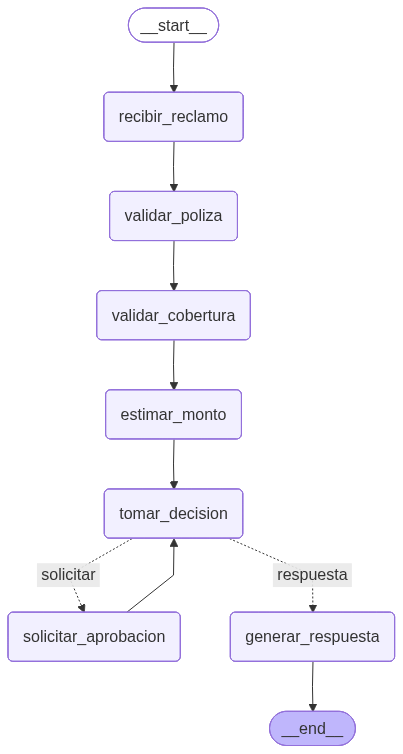

In [5]:
from IPython.display import Image, display
display(Image(reclamo_graph.get_graph().draw_mermaid_png()))